<a href="https://colab.research.google.com/github/sabarish-3505/self-project/blob/main/brain_tumor_classifier_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor MRI Classification (Google Colab)

Classifies brain MRI scans into **glioma, meningioma, pituitary, no_tumor** using a from-scratch CNN baseline and a fine-tuned ResNet18, with Grad-CAM visualizations for interpretability.

**Before running:** Runtime → Change runtime type → **T4 GPU**.

**Limitations:** trained on a single public dataset; MRI acquisition protocol, scanner vendor, and orientation vary across hospitals, and this model has not been validated on external data. Class labels are from the dataset's own annotations, not verified by a radiologist. This is a portfolio/learning project, not a diagnostic tool.

## 1. Get a Kaggle API token (one-time)

1. Go to https://www.kaggle.com/settings/account
2. Scroll to **API** → click **Create New Token** → this downloads `kaggle.json`
3. Run the cell below and upload that file when prompted

In [1]:
from google.colab import files
uploaded = files.upload()   # select the zip you downloaded

Saving archive (2).zip to archive (2).zip


In [2]:
import zipfile, os
zip_name = list(uploaded.keys())[0]  # picks whatever file you uploaded
os.makedirs("/content/data", exist_ok=True)
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall("/content/data")

print(os.listdir("/content/data"))

['Testing', 'Training']


## 2. Download the dataset

In [5]:
import os
DATA_DIR = "/content/data"
print(os.listdir(DATA_DIR))

['Testing', 'Training']


## 3. Setup

In [6]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type != "cuda":
    print("WARNING: no GPU detected — go to Runtime > Change runtime type > T4 GPU")

os.makedirs("/content/outputs", exist_ok=True)

Using device: cuda


## 4. Data loaders

In [7]:
TRAIN_DIR = os.path.join(DATA_DIR, "Training")
TEST_DIR = os.path.join(DATA_DIR, "Testing")

IMG_SIZE = 224
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_ds = datasets.ImageFolder(TEST_DIR, transform=test_transform)
classes = train_ds.classes
print("Classes:", classes)
print("Train size:", len(train_ds), "| Test size:", len(test_ds))

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train size: 5600 | Test size: 1600


## 5. Models: baseline CNN + ResNet18

In [8]:
class BaselineCNN(nn.Module):
    """From-scratch CNN — comparison point against the transfer-learning model."""
    def __init__(self, num_classes=4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(), nn.Dropout(0.3), nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))


def build_resnet18(num_classes=4, freeze_backbone=True):
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    model.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(model.fc.in_features, num_classes))
    return model


def get_model(name, num_classes=4, freeze_backbone=True):
    if name == "baseline":
        return BaselineCNN(num_classes)
    elif name == "resnet18":
        return build_resnet18(num_classes, freeze_backbone)
    raise ValueError(name)

## 6. Training loop

In [9]:
def run_epoch(model, loader, criterion, optimizer, train):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for images, labels in tqdm(loader, leave=False):
            images, labels = images.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)
    return total_loss / total, correct / total


def train_model(model_name, epochs=10, lr=1e-3, freeze_backbone=True):
    model = get_model(model_name, num_classes=len(classes), freeze_backbone=freeze_backbone).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    best_acc = 0.0
    ckpt_path = f"/content/outputs/{model_name}_best.pt"

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
        val_loss, val_acc = run_epoch(model, test_loader, criterion, optimizer, train=False)
        print(f"Epoch {epoch}/{epochs} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save({"model_state_dict": model.state_dict(), "classes": classes,
                        "model_name": model_name, "val_acc": val_acc}, ckpt_path)
            print(f"  -> saved new best checkpoint ({val_acc:.4f})")

    print(f"\nBest val accuracy: {best_acc:.4f} | checkpoint: {ckpt_path}")
    return ckpt_path

## 7. Run training

Train the ResNet18 first (recommended — much faster to converge, higher accuracy). Uncomment the baseline line if you also want the from-scratch comparison for your README.

In [10]:
resnet_ckpt = train_model("resnet18", epochs=10, freeze_backbone=True)

# baseline_ckpt = train_model("baseline", epochs=15)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 186MB/s]


  0%|          | 0/175 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1/10 | train_loss=0.7768 train_acc=0.7027 | val_loss=0.6354 val_acc=0.7744
  -> saved new best checkpoint (0.7744)


...

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 9/10 | train_loss=0.4373 train_acc=0.8423 | val_loss=0.5277 val_acc=0.8244


  0%|          | 0/175 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 10/10 | train_loss=0.4518 train_acc=0.8273 | val_loss=0.5443 val_acc=0.8163

Best val accuracy: 0.8363 | checkpoint: /content/outputs/resnet18_best.pt


## 8. Evaluate: confusion matrix + classification report

              precision    recall  f1-score   support

      glioma       0.87      0.69      0.77       400
  meningioma       0.71      0.76      0.73       400
     notumor       0.87      0.97      0.92       400
   pituitary       0.91      0.93      0.92       400

    accuracy                           0.84      1600
   macro avg       0.84      0.84      0.83      1600
weighted avg       0.84      0.84      0.83      1600



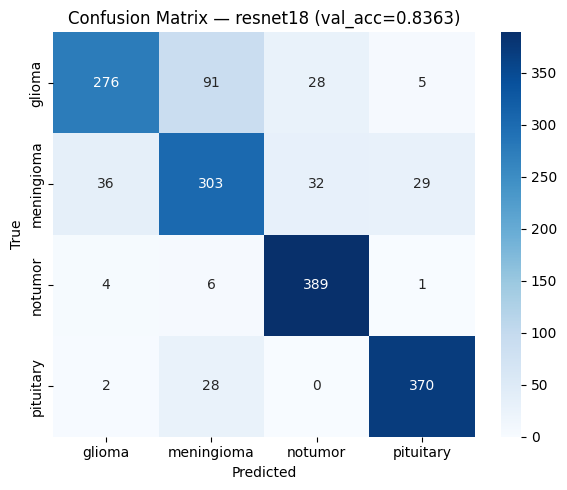

In [11]:
def evaluate(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)
    model = get_model(ckpt["model_name"], num_classes=len(ckpt["classes"]))
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device).eval()

    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            preds = model(images).argmax(1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.tolist())

    print(classification_report(all_labels, all_preds, target_names=ckpt["classes"]))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=ckpt["classes"], yticklabels=ckpt["classes"])
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.title(f"Confusion Matrix — {ckpt['model_name']} (val_acc={ckpt['val_acc']:.4f})")
    plt.tight_layout()
    plt.savefig("/content/outputs/confusion_matrix.png", dpi=150)
    plt.show()
    return model

model = evaluate(resnet_ckpt)

## 9. Grad-CAM — model interpretability

Shows which regions of the MRI the model used to make its prediction. This is the piece that makes the project stand out beyond a plain accuracy number.

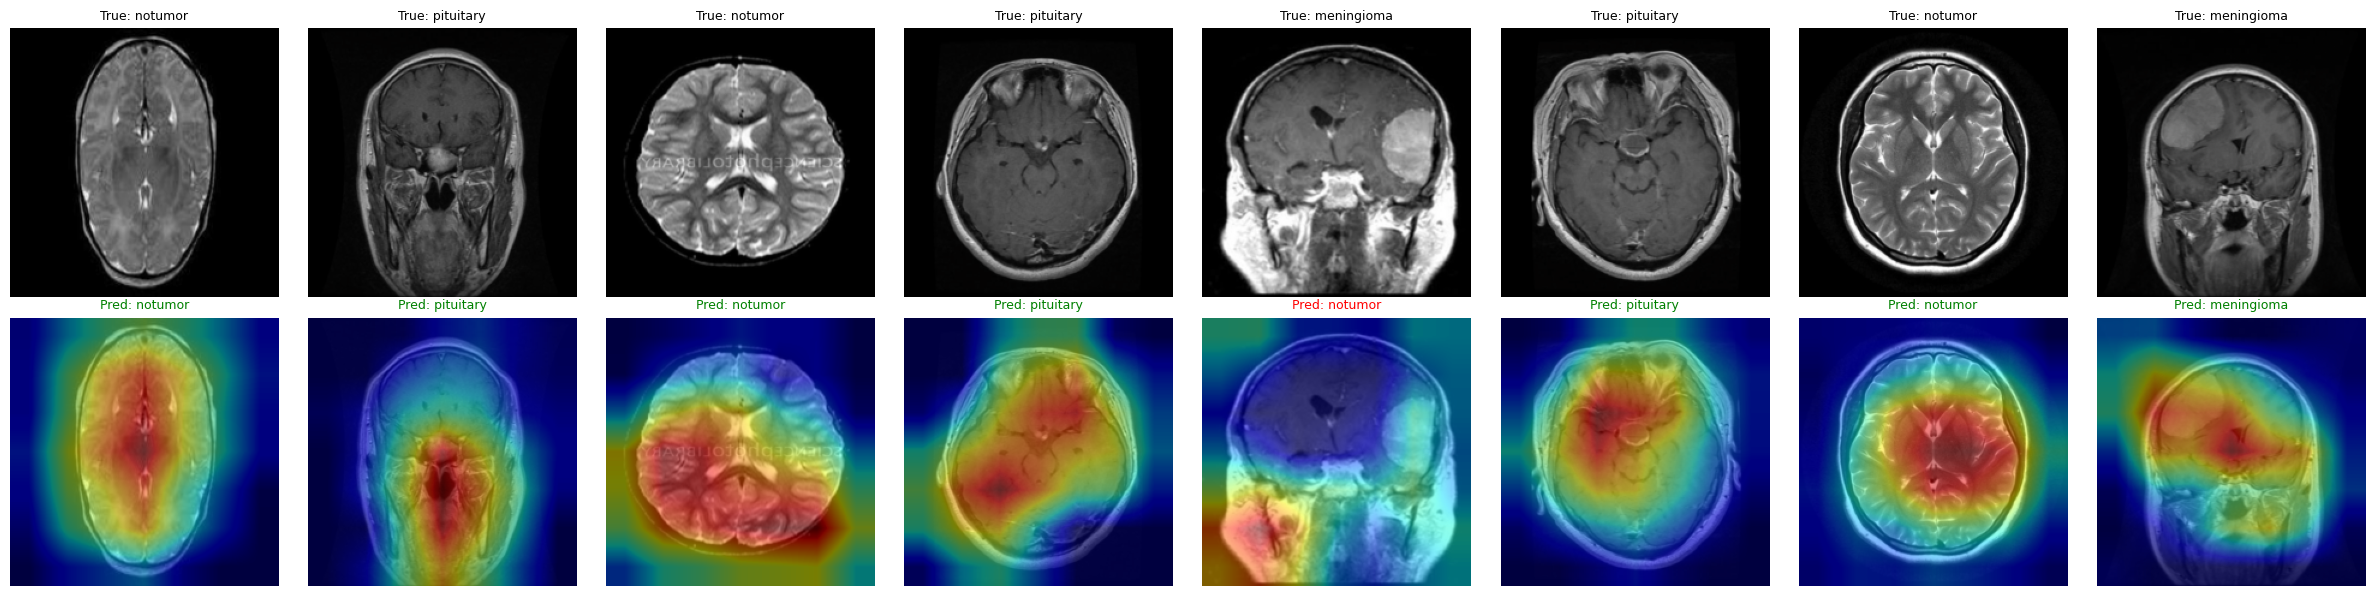

In [13]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        input_tensor = input_tensor.clone().requires_grad_(True)   # <-- add this line
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

    def __call__(self, input_tensor, class_idx=None):
        return self.generate(input_tensor, class_idx)


def unnormalize(img_tensor):
    mean = torch.tensor(NORM_MEAN).view(3, 1, 1)
    std = torch.tensor(NORM_STD).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()


target_layer = model.layer4[-1].conv2
cam_generator = GradCAM(model, target_layer)

single_loader = DataLoader(test_ds, batch_size=1, shuffle=True)
num_images = 8
fig, axes = plt.subplots(2, num_images, figsize=(3 * num_images, 6))

for i, (image, label) in enumerate(single_loader):
    if i >= num_images:
        break
    image = image.to(device)
    cam, pred_class = cam_generator.generate(image)
    img_np = unnormalize(image[0])

    axes[0, i].imshow(img_np); axes[0, i].set_title(f"True: {classes[label.item()]}", fontsize=9); axes[0, i].axis("off")
    axes[1, i].imshow(img_np); axes[1, i].imshow(cam, cmap="jet", alpha=0.5)
    color = "green" if pred_class == label.item() else "red"
    axes[1, i].set_title(f"Pred: {classes[pred_class]}", fontsize=9, color=color); axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("/content/outputs/gradcam_examples.png", dpi=150)
plt.show()